[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sonder-art/ia_p26/blob/main/clase/15_adversarial_search/notebooks/02_minimax_y_alphabeta.ipynb)

# Minimax y Alpha-beta

**Módulo 15 — Búsqueda Adversarial · Notebook 02**

---

## ¿De qué trata este notebook?

Este notebook es **autocontenido**: incluye todo lo necesario para entender
y experimentar con Minimax y Alpha-beta sin necesidad de notas previas.

**Lo que vas a construir y explorar:**

1. **Minimax con log de llamadas**: traza paso a paso cada llamada recursiva.
2. **Minimax a escala**: heatmap de nodos expandidos para distintos Nim(a,b).
3. **Alpha-beta con log**: misma traza, ahora con valores α/β y podas marcadas.
4. **Heatmap comparativo**: ahorro de alpha-beta sobre minimax (ratio).
5. **Experimento de ordenamiento**: ¿cuánto importa el orden de los movimientos?
6. **Verificación de equivalencia**: demostración de que ambos dan la misma respuesta.
7. **(Ir más lejos) Tablas de transposición**: memoización para grafos de juego.

**Relación con notas de clase:** secciones 15.3 (Minimax) y 15.4 (Alpha-beta).

**Prerequisito:** Notebook 01 de este módulo (o conocer las clases `Nim` y `TicTacToe`).

---

### El problema central

Tenemos el árbol de juego. La pregunta es: **¿qué acción debe elegir MAX?**

La respuesta intuitiva: MAX debe elegir la acción que lleve al estado más
valioso — donde "valioso" significa que, sin importar lo que haga MIN, MAX
obtenga el mejor resultado posible.

Formalizar esta intuición es exactamente lo que hace el algoritmo **Minimax**.

El problema con Minimax es que recorre **todo** el árbol, que puede ser
astronómicamente grande (Chess: $10^{123}$ nodos). El algoritmo **Alpha-beta**
resuelve esto: descarta ramas que **garantizadamente no pueden influir** en
la decisión final, sin perder optimalidad.

In [3]:
# Solo en Colab
import sys
if "google.colab" in sys.modules:
    !pip install -q numpy matplotlib pandas

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from abc import ABC, abstractmethod
import random
import time
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

COLORS = {
    "max":     "#2E86AB",
    "min":     "#E94F37",
    "win":     "#27AE60",
    "lose":    "#7F8C8D",
    "pruned":  "#F39C12",
    "edge":    "#2C3E50",
    "ab":      "#8E44AD",
}

print("Dependencias cargadas correctamente.")

Dependencias cargadas correctamente.


---
## Infraestructura: clases de juego (autocontenida)

Reproducimos aquí las clases del Notebook 01 para que este notebook
funcione de forma independiente.

In [6]:
class Juego(ABC):
    """Interfaz base para juegos de dos jugadores suma-cero."""

    @abstractmethod
    def estado_inicial(self): pass

    @abstractmethod
    def jugador(self, estado): pass

    @abstractmethod
    def acciones(self, estado): pass

    @abstractmethod
    def resultado(self, estado, accion): pass

    @abstractmethod
    def terminal(self, estado): pass

    @abstractmethod
    def utilidad(self, estado, jugador='MAX'): pass


class Nim(Juego):
    """
    Nim de k pilas. El jugador que toma la ultima ficha GANA.
    Estado: tupla de enteros. Accion: (pile_idx, cantidad).
    Utilidad siempre desde perspectiva de MAX (+1 MAX gana, -1 MAX pierde).
    """

    def __init__(self, pilas):
        self.pilas_iniciales = tuple(pilas)
        self._suma_inicial = sum(self.pilas_iniciales)

    def estado_inicial(self):
        return self.pilas_iniciales

    def jugador(self, estado):
        return "MAX" if sum(estado) % 2 == self._suma_inicial % 2 else "MIN"

    def acciones(self, estado):
        return [(i, c) for i, p in enumerate(estado) for c in range(1, p + 1)]

    def resultado(self, estado, accion):
        idx, amt = accion
        nuevo = list(estado)
        nuevo[idx] -= amt
        return tuple(nuevo)

    def terminal(self, estado):
        return all(p == 0 for p in estado)

    def utilidad(self, estado, jugador='MAX'):
        return -1 if self.jugador(estado) == "MAX" else +1

    def __repr__(self):
        return f"Nim({list(self.pilas_iniciales)})"


class TicTacToe(Juego):
    """
    Tic-tac-toe 3x3. MAX=X, MIN=O.
    Estado: tupla de 9 strings ('', 'X', 'O').
    """

    LINEAS = [
        [0,1,2],[3,4,5],[6,7,8],
        [0,3,6],[1,4,7],[2,5,8],
        [0,4,8],[2,4,6],
    ]

    def estado_inicial(self): return tuple([''] * 9)

    def jugador(self, estado):
        return 'MAX' if estado.count('X') == estado.count('O') else 'MIN'

    def acciones(self, estado):
        return [i for i, c in enumerate(estado) if c == '']

    def resultado(self, estado, accion):
        ficha = 'X' if self.jugador(estado) == 'MAX' else 'O'
        nuevo = list(estado)
        nuevo[accion] = ficha
        return tuple(nuevo)

    def _ganador(self, estado):
        for l in self.LINEAS:
            f = [estado[i] for i in l]
            if f[0] != '' and f[0] == f[1] == f[2]:
                return f[0]
        return None

    def terminal(self, estado):
        return self._ganador(estado) is not None or '' not in estado

    def utilidad(self, estado, jugador='MAX'):
        g = self._ganador(estado)
        return +1 if g == 'X' else (-1 if g == 'O' else 0)

    def mostrar(self, estado):
        s = {'': '.', 'X': 'X', 'O': 'O'}
        for f in range(3):
            print(' | '.join(s[estado[f*3+c]] for c in range(3)))
            if f < 2: print('-' * 9)


print("Clases Juego, Nim y TicTacToe definidas.")

# Test rápido
nim12 = Nim([1, 2])
s = nim12.estado_inicial()
print(f"Nim(1,2) inicio: {s}, jugador: {nim12.jugador(s)}, "
      f"acciones: {nim12.acciones(s)}")

Clases Juego, Nim y TicTacToe definidas.
Nim(1,2) inicio: (1, 2), jugador: MAX, acciones: [(0, 1), (1, 1), (1, 2)]


---
## Parte 1: Minimax — la idea

### Definición recursiva

El **valor Minimax** de un estado $s$ es:

$$
\text{minimax}(s) =
\begin{cases}
\text{UTILITY}(s) & \text{si } s \text{ es terminal} \\
\max_{a \in \text{ACTIONS}(s)} \text{minimax}(\text{RESULT}(s,a)) & \text{si PLAYER}(s) = MAX \\
\min_{a \in \text{ACTIONS}(s)} \text{minimax}(\text{RESULT}(s,a)) & \text{si PLAYER}(s) = MIN
\end{cases}
$$

En palabras:
- En estados terminales, devolvemos la utilidad directamente.
- Cuando es turno de MAX, elige la acción cuyo sucesor tiene el **máximo** valor.
- Cuando es turno de MIN, elige la acción cuyo sucesor tiene el **mínimo** valor.

### Conexión con DFS

Minimax es esencialmente un **DFS post-order** (primero expandimos hijos,
luego calculamos el valor del padre). Esto tiene implicaciones prácticas:

- **Complejidad temporal**: $O(b^d)$ — igual que DFS.
- **Complejidad espacial**: $O(b \cdot d)$ — solo necesitamos la pila de recursión,
  **no** almacenamos todo el árbol.

### ¿Por qué Minimax es óptimo?

El valor Minimax es el mejor resultado que MAX puede **garantizar** cuando MIN
juega perfectamente. Si MAX juega según Minimax y MIN *no* juega óptimamente,
MAX obtiene **al menos** el valor Minimax (posiblemente más).

Formalmente: si $v^* = \text{minimax}(s_0)$ y MAX sigue la estrategia Minimax,
entonces en cualquier partida el resultado final satisface
$\text{UTILITY} \geq v^*$ para MAX.

In [8]:
def minimax_log(estado, es_max, juego, log=None, nivel=0):
    """
    Minimax con registro completo de cada llamada recursiva.

    Parametros
    ----------
    estado  : estado actual del juego
    es_max  : True si es turno de MAX, False si es turno de MIN
    juego   : instancia de Juego
    log     : lista donde acumulamos entradas de traza (None = crear nueva)
    nivel   : profundidad actual (0 = raiz)

    Retorna
    -------
    (valor, accion_optima, log)
    """
    if log is None:
        log = []

    # ── Caso base: estado terminal ────────────────────────────────────────────
    if juego.terminal(estado):
        util = juego.utilidad(estado, 'MAX')
        log.append({
            'llamada':  'TERMINAL',
            'estado':   str(estado),
            'jugador':  'terminal',
            'nivel':    nivel,
            'retorna':  util,
            'nota':     f'util = {util}'
        })
        return util, None, log

    # ── Registrar entrada de esta llamada ─────────────────────────────────────
    jugador_str = 'MAX' if es_max else 'MIN'
    fn_nombre   = 'max_value' if es_max else 'min_value'
    log.append({
        'llamada':  fn_nombre,
        'estado':   str(estado),
        'jugador':  jugador_str,
        'nivel':    nivel,
        'retorna':  '...',    # se actualizará
        'nota':     ''
    })
    idx_entrada = len(log) - 1  # posición para actualizar después

    # ── Caso recursivo ────────────────────────────────────────────────────────
    mejor_valor  = float('-inf') if es_max else float('inf')
    mejor_accion = None

    for accion in juego.acciones(estado):
        sucesor = juego.resultado(estado, accion)
        v, _, log = minimax_log(sucesor, not es_max, juego, log, nivel + 1)

        if es_max and v > mejor_valor:
            mejor_valor  = v
            mejor_accion = accion
        elif not es_max and v < mejor_valor:
            mejor_valor  = v
            mejor_accion = accion

    # Actualizar la entrada de esta llamada con el valor de retorno
    log[idx_entrada]['retorna'] = mejor_valor
    log[idx_entrada]['nota']    = (
        f"max de hijos → mejor accion: {mejor_accion}" if es_max
        else f"min de hijos → mejor accion: {mejor_accion}"
    )

    return mejor_valor, mejor_accion, log


print("minimax_log definido.")

minimax_log definido.


In [9]:
# --- Traza completa de Minimax sobre Nim(1,2) ---

nim12  = Nim([1, 2])
s0     = nim12.estado_inicial()
valor, accion_opt, log = minimax_log(s0, True, nim12)

print(f"Decisión Minimax para Nim(1,2):")
print(f"  Acción óptima: {accion_opt}  "
      f"(retirar {accion_opt[1]} de pila {accion_opt[0]})")
print(f"  Valor garantizado: {valor}  "
      f"({'MAX gana' if valor > 0 else 'MIN gana' if valor < 0 else 'empate'})")
print(f"  Total de llamadas registradas: {len(log)}\n")

# Tabla de traza
df = pd.DataFrame(log)[['llamada', 'estado', 'jugador', 'nivel', 'retorna', 'nota']]
df.index = range(1, len(df) + 1)
df.columns = ['Llamada', 'Estado', 'Jugador', 'Nivel', 'Retorna', 'Nota']

print("Traza completa de Minimax en Nim(1,2):")
print(df.to_string())

print(f"\n{'='*70}")
print("Observaciones:")
print("  - Filas con Llamada='TERMINAL' son los casos base.")
print("  - Las filas 'max_value'/'min_value' se llenan en orden POST-ORDER:")
print("    el valor 'Retorna' se actualiza después de expandir todos los hijos.")
print("  - El indentado implícito en 'Nivel' muestra la pila de recursión.")

Decisión Minimax para Nim(1,2):
  Acción óptima: (0, 1)  (retirar 1 de pila 0)
  Valor garantizado: 1  (MAX gana)
  Total de llamadas registradas: 12

Traza completa de Minimax en Nim(1,2):
      Llamada  Estado   Jugador  Nivel  Retorna                                 Nota
1   max_value  (1, 2)       MAX      0        1  max de hijos → mejor accion: (0, 1)
2   min_value  (0, 2)       MIN      1        1  min de hijos → mejor accion: (1, 1)
3   max_value  (0, 1)       MAX      2        1  max de hijos → mejor accion: (1, 1)
4    TERMINAL  (0, 0)  terminal      3        1                             util = 1
5    TERMINAL  (0, 0)  terminal      2        1                             util = 1
6   min_value  (1, 1)       MIN      1        1  min de hijos → mejor accion: (0, 1)
7   max_value  (0, 1)       MAX      2        1  max de hijos → mejor accion: (1, 1)
8    TERMINAL  (0, 0)  terminal      3        1                             util = 1
9   max_value  (1, 0)       MAX      2       

### Lectura de la traza

La tabla anterior registra **cada llamada recursiva** de Minimax. Cómo leerla:

1. **Llamada = `max_value`**: MAX está evaluando este estado; tomará el máximo
   de los valores de sus hijos.
2. **Llamada = `min_value`**: MIN está evaluando este estado; tomará el mínimo.
3. **Llamada = `TERMINAL`**: estado hoja; el valor retornado es la utilidad directa.
4. **Nivel**: profundidad en el árbol (0 = raíz). El orden de las filas muestra
   exactamente el orden en que DFS visita los nodos.

Nota importante: la fila para un nodo interno aparece **antes** que sus hijos
(con `Retorna = '...'`), y su valor se completa en la misma fila cuando todos
los hijos han sido evaluados. Esto refleja la naturaleza post-order de la recursión.

En la implementación real la actualización es en el mismo slot del log, pero
la tabla la muestra como si el valor estuviera disponible desde el principio.

In [11]:
def minimax_contar(estado, es_max, juego):
    """
    Minimax que cuenta nodos expandidos (sin log de texto, mas eficiente).

    Retorna (valor, accion_optima, nodos_expandidos).
    """
    if juego.terminal(estado):
        return juego.utilidad(estado, 'MAX'), None, 1

    mejor_valor  = float('-inf') if es_max else float('inf')
    mejor_accion = None
    nodos        = 1   # contar este nodo

    for accion in juego.acciones(estado):
        sucesor = juego.resultado(estado, accion)
        v, _, n = minimax_contar(sucesor, not es_max, juego)
        nodos += n

        if es_max and v > mejor_valor:
            mejor_valor  = v
            mejor_accion = accion
        elif not es_max and v < mejor_valor:
            mejor_valor  = v
            mejor_accion = accion

    return mejor_valor, mejor_accion, nodos


print("minimax_contar definido.")

# Verificación rápida
v, a, n = minimax_contar(nim12.estado_inicial(), True, nim12)
print(f"Nim(1,2): valor={v}, acción={a}, nodos={n}")

minimax_contar definido.
Nim(1,2): valor=1, acción=(0, 1), nodos=12


---
## Parte 2: Minimax a escala

Veamos cómo crece el número de nodos expandidos conforme aumentamos el
tamaño del juego. Para Nim(a,b) con $a, b \in \{0, \ldots, 4\}$ generamos
un heatmap del costo de Minimax.

Observaciones que esperamos ver:
- El costo crece rápido: incluso Nim(4,4) tiene miles de nodos.
- El crecimiento no es puramente $b^d$ porque las pilas se agotan y
  el factor de ramificación decrece con el juego.

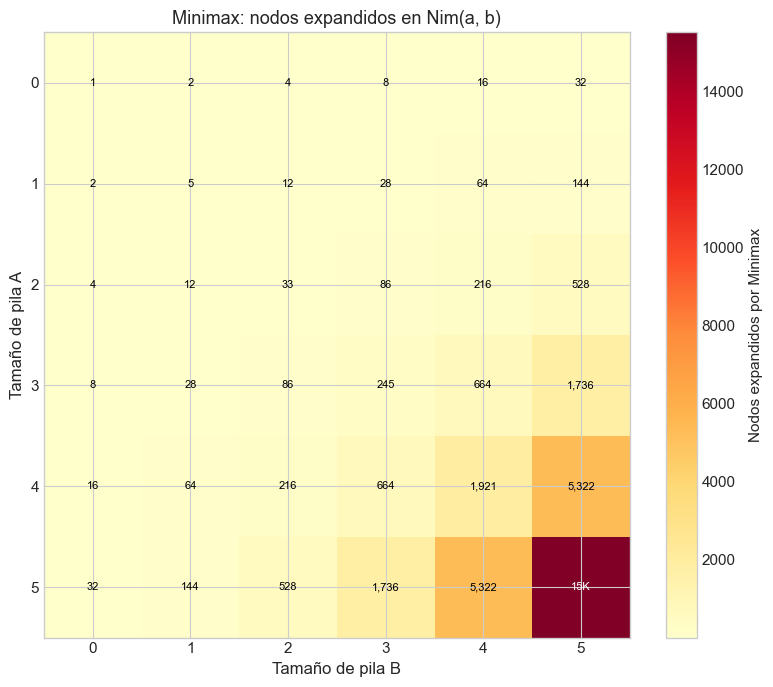

Caso más costoso en esta grilla: Nim(5, 5) = 15,525 nodos


In [13]:
MAX_PILA = 6   # pilas de 0 a 5
counts_mm = np.zeros((MAX_PILA, MAX_PILA), dtype=int)

for a in range(MAX_PILA):
    for b in range(MAX_PILA):
        nim_ab = Nim([a, b])
        s0 = nim_ab.estado_inicial()
        if nim_ab.terminal(s0):
            counts_mm[a, b] = 1
        else:
            _, _, n = minimax_contar(s0, True, nim_ab)
            counts_mm[a, b] = n

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(counts_mm, cmap='YlOrRd', aspect='auto', interpolation='nearest')
plt.colorbar(im, ax=ax, label='Nodos expandidos por Minimax')

ax.set_xlabel('Tamaño de pila B', fontsize=12)
ax.set_ylabel('Tamaño de pila A', fontsize=12)
ax.set_title('Minimax: nodos expandidos en Nim(a, b)', fontsize=13)
ax.set_xticks(range(MAX_PILA))
ax.set_yticks(range(MAX_PILA))

for a in range(MAX_PILA):
    for b in range(MAX_PILA):
        val = counts_mm[a, b]
        txt = f'{val:,}' if val < 10000 else f'{val//1000}K'
        dark = val > counts_mm.max() * 0.55
        ax.text(b, a, txt, ha='center', va='center', fontsize=8,
                color='white' if dark else 'black')

plt.tight_layout()
plt.show()

print(f"Caso más costoso en esta grilla: "
      f"Nim({np.unravel_index(counts_mm.argmax(), counts_mm.shape)[0]}, "
      f"{np.unravel_index(counts_mm.argmax(), counts_mm.shape)[1]}) "
      f"= {counts_mm.max():,} nodos")

---
## Parte 3: Alpha-beta — la idea

### El problema de Minimax

Minimax garantiza la solución óptima, pero a un costo $O(b^d)$ que crece
exponencialmente. Para ajedrez ($b \approx 35$, $d \approx 80$): impracticable.

### La observación clave de Alpha-beta

Al recorrer el árbol de derecha a izquierda y luego de izquierda a derecha,
hay nodos que **definitivamente no influyen** en la decisión de la raíz.
Podemos ignorarlos sin perder optimalidad.

**Ejemplo intuitivo:**

```
MAX decide entre A y B:
  A ya evaluó → valor = 3
  B: MIN evaluará sus hijos...
     B tiene un hijo con valor 2
     → MIN tomará ≤ 2 desde B
     → MAX prefiere A (3 > 2)
     → Los demás hijos de B son IRRELEVANTES — podamos.
```

### Los parámetros α y β

- **α (alpha)**: el mejor valor que MAX puede garantizar en el camino actual
  (cota inferior para MAX). Empieza en $-\infty$.
- **β (beta)**: el mejor valor que MIN puede garantizar en el camino actual
  (cota superior para MIN). Empieza en $+\infty$.

**Condición de poda:**
- **Poda beta** (en nodo MAX): si el valor actual $\geq \beta$, MIN nunca
  permitirá llegar aquí → podamos los hermanos restantes.
- **Poda alpha** (en nodo MIN): si el valor actual $\leq \alpha$, MAX nunca
  elegirá llegar aquí → podamos los hermanos restantes.

En resumen: $\alpha \leq \text{valor real} \leq \beta$ siempre. Si esto
se viola, la rama no puede mejorar la decisión actual.

### Equivalencia con Minimax

**Teorema:** Alpha-beta retorna exactamente el mismo valor y la misma
acción óptima que Minimax, para cualquier juego suma-cero. Solo difiere
en cuántos nodos expande.

Lo demostraremos empíricamente al final del notebook.

In [15]:
def alphabeta_log(estado, es_max, juego,
                   alpha=float('-inf'), beta=float('inf'),
                   log=None, nivel=0):
    """
    Alpha-beta con registro completo incluyendo valores alpha/beta por llamada.

    Parametros
    ----------
    estado  : estado actual
    es_max  : True = turno de MAX
    juego   : instancia de Juego
    alpha   : cota inferior actual (mejor para MAX en el camino)
    beta    : cota superior actual (mejor para MIN en el camino)
    log     : lista de traza
    nivel   : profundidad

    Retorna
    -------
    (valor, accion_optima, log)
    """
    if log is None:
        log = []

    # ── Caso base ─────────────────────────────────────────────────────────────
    if juego.terminal(estado):
        util = juego.utilidad(estado, 'MAX')
        log.append({
            'llamada': 'TERMINAL',
            'estado':  str(estado),
            'jugador': 'terminal',
            'nivel':   nivel,
            'alpha':   alpha,
            'beta':    beta,
            'retorna': util,
            'nota':    f'util = {util}'
        })
        return util, None, log

    # ── Registrar entrada ─────────────────────────────────────────────────────
    jugador_str = 'MAX' if es_max else 'MIN'
    fn_nombre   = 'max_ab' if es_max else 'min_ab'
    log.append({
        'llamada': fn_nombre,
        'estado':  str(estado),
        'jugador': jugador_str,
        'nivel':   nivel,
        'alpha':   alpha,
        'beta':    beta,
        'retorna': '...',
        'nota':    ''
    })
    idx = len(log) - 1

    # ── Recursión con poda ────────────────────────────────────────────────────
    mejor_valor  = float('-inf') if es_max else float('inf')
    mejor_accion = None
    podado       = False

    for accion in juego.acciones(estado):
        sucesor = juego.resultado(estado, accion)
        v, _, log = alphabeta_log(sucesor, not es_max, juego,
                                   alpha, beta, log, nivel + 1)

        if es_max:
            if v > mejor_valor:
                mejor_valor  = v
                mejor_accion = accion
            alpha = max(alpha, mejor_valor)
            if mejor_valor >= beta:
                log[idx]['nota'] = (f'PODA-beta: valor {mejor_valor} '
                                    f'>= beta {beta}')
                podado = True
                break
        else:
            if v < mejor_valor:
                mejor_valor  = v
                mejor_accion = accion
            beta = min(beta, mejor_valor)
            if mejor_valor <= alpha:
                log[idx]['nota'] = (f'PODA-alpha: valor {mejor_valor} '
                                    f'<= alpha {alpha}')
                podado = True
                break

    if not podado:
        log[idx]['nota'] = f'sin poda → mejor accion: {mejor_accion}'

    log[idx]['retorna'] = mejor_valor
    return mejor_valor, mejor_accion, log


print("alphabeta_log definido.")

alphabeta_log definido.


In [16]:
# --- Traza de Alpha-beta sobre Nim(2,3) ---
# (un juego un poco más grande para mostrar podas)

nim23 = Nim([2, 3])
s0    = nim23.estado_inicial()

# Primero Minimax para comparar
v_mm, a_mm, log_mm = minimax_log(s0, True, nim23)
# Luego Alpha-beta
v_ab, a_ab, log_ab = alphabeta_log(s0, True, nim23)

print(f"Nim(2,3) — Minimax: valor={v_mm}, acción={a_mm}, llamadas={len(log_mm)}")
print(f"Nim(2,3) — Alpha-beta: valor={v_ab}, acción={a_ab}, llamadas={len(log_ab)}")
print(f"Ahorro de llamadas: {len(log_mm) - len(log_ab)} "
      f"({100*(1 - len(log_ab)/len(log_mm)):.1f}% reducción)")

print("\nTraza Alpha-beta (muestra las primeras 30 filas + las que tienen PODA):")
df_ab = pd.DataFrame(log_ab)[['llamada','estado','jugador','nivel',
                               'alpha','beta','retorna','nota']]
df_ab.index = range(1, len(df_ab) + 1)
df_ab.columns = ['Llamada','Estado','Jugador','Nivel','Alpha','Beta','Retorna','Nota']

# Mostrar primeras 30 filas
print(df_ab.head(30).to_string())

# Filas con podas
podas = df_ab[df_ab['Nota'].str.startswith('PODA')]
if len(podas) > 0:
    print(f"\n--- {len(podas)} poda(s) detectada(s): ---")
    print(podas.to_string())

Nim(2,3) — Minimax: valor=1, acción=(0, 1), llamadas=86
Nim(2,3) — Alpha-beta: valor=1, acción=(0, 1), llamadas=44
Ahorro de llamadas: 42 (48.8% reducción)

Traza Alpha-beta (muestra las primeras 30 filas + las que tienen PODA):
     Llamada  Estado   Jugador  Nivel  Alpha  Beta  Retorna                             Nota
1     max_ab  (2, 3)       MAX      0   -inf   inf        1  sin poda → mejor accion: (0, 1)
2     min_ab  (1, 3)       MIN      1   -inf   inf        1  sin poda → mejor accion: (0, 1)
3     max_ab  (0, 3)       MAX      2   -inf   inf        1  sin poda → mejor accion: (1, 1)
4     min_ab  (0, 2)       MIN      3   -inf   inf        1  sin poda → mejor accion: (1, 1)
5     max_ab  (0, 1)       MAX      4   -inf   inf        1  sin poda → mejor accion: (1, 1)
6   TERMINAL  (0, 0)  terminal      5   -inf   inf        1                         util = 1
7   TERMINAL  (0, 0)  terminal      4   -inf   1.0        1                         util = 1
8     min_ab  (0, 1)       

### Interpretando las podas

Cada fila marcada con `PODA-beta` o `PODA-alpha` en la traza representa un
punto donde Alpha-beta decidió **no evaluar** los hijos restantes de ese nodo.

**PODA-beta** ocurre en un nodo MAX cuando el valor encontrado hasta ahora
$\geq \beta$. Esto significa:
> "Ya sé que MAX puede obtener al menos este valor aquí. Pero el ancestro MIN
> ya tiene una opción mejor (≤ beta). MIN nunca dejará que MAX llegue aquí.
> Los hermanos restantes no importan."

**PODA-alpha** ocurre en un nodo MIN cuando el valor encontrado $\leq \alpha$:
> "Ya sé que MIN puede obtener como mucho este valor aquí. Pero el ancestro MAX
> ya tiene una opción mejor (≥ alpha). MAX nunca elegirá llegar aquí."

Las columnas `Alpha` y `Beta` muestran los valores de las ventanas en el momento
de la llamada, lo que permite rastrear exactamente cuándo se activan las podas.

---
## Parte 4: Heatmap comparativo Minimax vs Alpha-beta

In [19]:
def alphabeta_contar(estado, es_max, juego,
                      alpha=float('-inf'), beta=float('inf'),
                      shuffle=False):
    """
    Alpha-beta contando nodos. shuffle=True para orden aleatorio de acciones.

    Retorna (valor, accion_optima, nodos_expandidos).
    """
    if juego.terminal(estado):
        return juego.utilidad(estado, 'MAX'), None, 1

    mejor_valor  = float('-inf') if es_max else float('inf')
    mejor_accion = None
    nodos        = 1

    acciones = juego.acciones(estado)
    if shuffle:
        acciones = list(acciones)
        random.shuffle(acciones)

    for accion in acciones:
        sucesor = juego.resultado(estado, accion)
        v, _, n = alphabeta_contar(sucesor, not es_max, juego, alpha, beta, shuffle)
        nodos += n

        if es_max:
            if v > mejor_valor:
                mejor_valor  = v
                mejor_accion = accion
            alpha = max(alpha, mejor_valor)
            if mejor_valor >= beta:
                break   # poda beta
        else:
            if v < mejor_valor:
                mejor_valor  = v
                mejor_accion = accion
            beta = min(beta, mejor_valor)
            if mejor_valor <= alpha:
                break   # poda alpha

    return mejor_valor, mejor_accion, nodos


print("alphabeta_contar definido.")

# Verificación rápida
v_ab, a_ab, n_ab = alphabeta_contar(nim12.estado_inicial(), True, nim12)
v_mm, a_mm, n_mm = minimax_contar(nim12.estado_inicial(), True, nim12)
print(f"Nim(1,2): Minimax={v_mm} ({n_mm} nodos), "
      f"Alpha-beta={v_ab} ({n_ab} nodos), "
      f"ahorro={100*(1-n_ab/n_mm):.1f}%")

alphabeta_contar definido.
Nim(1,2): Minimax=1 (12 nodos), Alpha-beta=1 (10 nodos), ahorro=16.7%


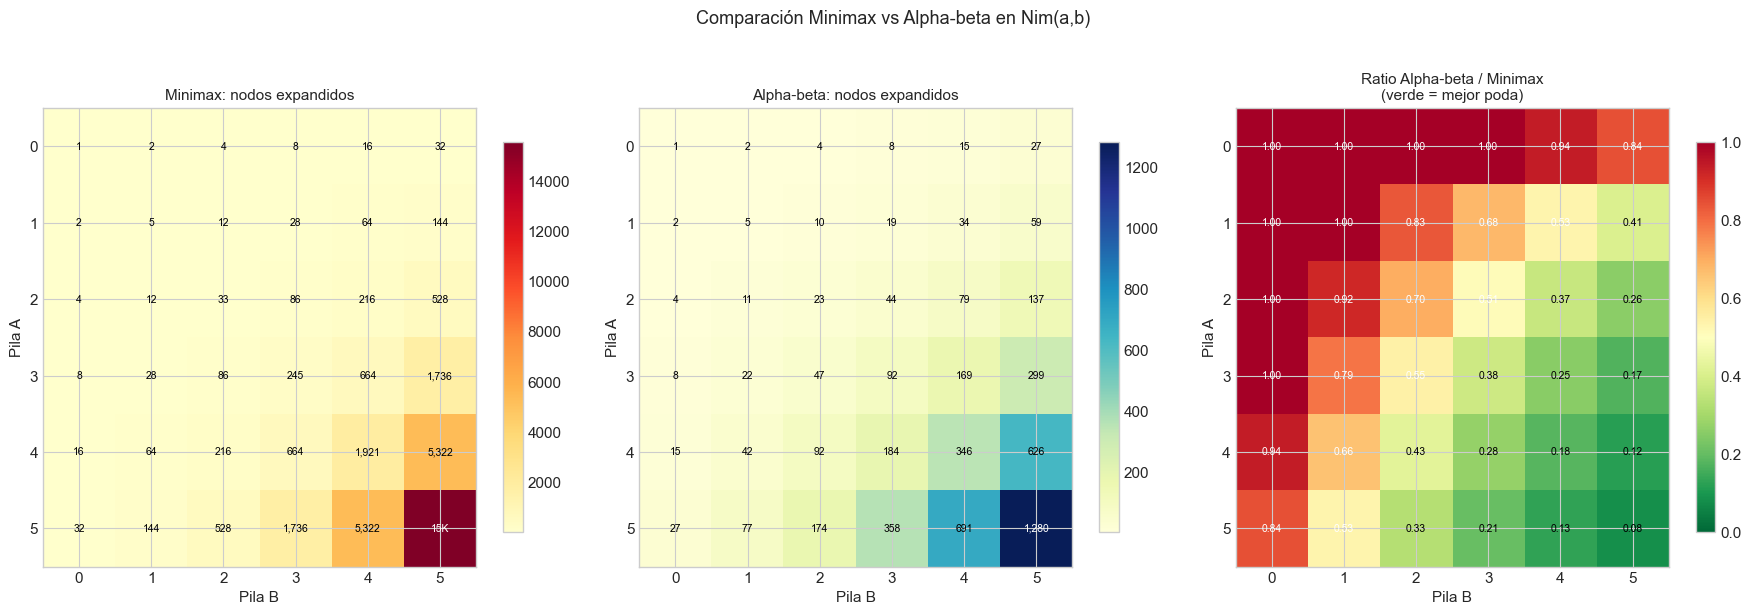

Ratio promedio (excluyendo triviales): 0.607
  Ratio mínimo (mejor poda):  0.082
  Ratio máximo (peor poda):   1.000
En promedio, Alpha-beta expande ~61% de los nodos de Minimax.


In [20]:
# Heatmap de Minimax, Alpha-beta y el ratio (reducción)

MAX_PILA = 6
counts_ab    = np.zeros((MAX_PILA, MAX_PILA), dtype=int)
counts_mm_2  = np.zeros((MAX_PILA, MAX_PILA), dtype=int)  # recalcular para la misma grilla
ratio_grid   = np.zeros((MAX_PILA, MAX_PILA))

for a in range(MAX_PILA):
    for b in range(MAX_PILA):
        nim_ab = Nim([a, b])
        s0 = nim_ab.estado_inicial()
        if nim_ab.terminal(s0):
            counts_mm_2[a, b] = 1
            counts_ab[a, b]   = 1
            ratio_grid[a, b]  = 1.0
        else:
            _, _, n_mm_v = minimax_contar(s0, True, nim_ab)
            _, _, n_ab_v = alphabeta_contar(s0, True, nim_ab)
            counts_mm_2[a, b] = n_mm_v
            counts_ab[a, b]   = n_ab_v
            ratio_grid[a, b]  = n_ab_v / n_mm_v

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

datos = [
    (counts_mm_2, 'YlOrRd',   'Minimax: nodos expandidos'),
    (counts_ab,   'YlGnBu',   'Alpha-beta: nodos expandidos'),
    (ratio_grid,  'RdYlGn_r', 'Ratio Alpha-beta / Minimax\n(verde = mejor poda)'),
]

for ax, (data, cmap, titulo) in zip(axes, datos):
    im = ax.imshow(data, cmap=cmap, aspect='auto', interpolation='nearest',
                   vmin=None if 'Ratio' not in titulo else 0,
                   vmax=None if 'Ratio' not in titulo else 1)
    plt.colorbar(im, ax=ax, shrink=0.85)
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel('Pila B')
    ax.set_ylabel('Pila A')
    ax.set_xticks(range(MAX_PILA))
    ax.set_yticks(range(MAX_PILA))

    for a_ in range(MAX_PILA):
        for b_ in range(MAX_PILA):
            val = data[a_, b_]
            if 'Ratio' in titulo:
                txt = f'{val:.2f}'
                dark = val > 0.5
            else:
                txt = f'{val:,}' if val < 10000 else f'{val//1000}K'
                dark = val > data.max() * 0.55
            ax.text(b_, a_, txt, ha='center', va='center', fontsize=7.5,
                    color='white' if dark else 'black')

plt.suptitle('Comparación Minimax vs Alpha-beta en Nim(a,b)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Resumen estadístico del ratio
ratios_nonzero = ratio_grid[ratio_grid < 1.0]
print(f"Ratio promedio (excluyendo triviales): {ratio_grid.mean():.3f}")
print(f"  Ratio mínimo (mejor poda):  {ratio_grid[1:,1:].min():.3f}")
print(f"  Ratio máximo (peor poda):   {ratio_grid.max():.3f}")
print(f"En promedio, Alpha-beta expande ~{100*ratio_grid.mean():.0f}% "
      f"de los nodos de Minimax.")

---
## Parte 5: El efecto del ordenamiento de movimientos

### ¿Por qué importa el orden?

Alpha-beta funciona mejor cuando **los mejores movimientos se evalúan primero**.
Si MAX ve el mejor movimiento al principio, la ventana $\alpha$ sube rápido
y se producen muchas podas beta.

En el caso ideal (orden perfecto), Alpha-beta expande solo $O(b^{d/2})$ nodos
— ¡la raíz cuadrada del costo de Minimax! Esto permite doblar la profundidad
de búsqueda para el mismo costo.

En el caso peor (orden inverso al óptimo), Alpha-beta no puede podar nada
y degenera a Minimax completo: $O(b^d)$ nodos.

El experimento siguiente mide el efecto del ordenamiento aleatorio
en 500 corridas con semillas distintas.

In [22]:
random.seed(42)

# Elegimos Nim(2,3,4) — suficientemente grande para ver variación
nim234 = Nim([2, 3, 4])
s0_234 = nim234.estado_inicial()

_, _, n_minimax  = minimax_contar(s0_234, True, nim234)
_, _, n_ab_ord   = alphabeta_contar(s0_234, True, nim234, shuffle=False)

n_ab_random_list = []
for _ in range(500):
    _, _, n = alphabeta_contar(s0_234, True, nim234, shuffle=True)
    n_ab_random_list.append(n)

print(f"Nim(2,3,4):")
print(f"  Minimax (sin poda):         {n_minimax:,} nodos")
print(f"  Alpha-beta (orden canónico): {n_ab_ord:,} nodos  "
      f"({100*n_ab_ord/n_minimax:.1f}% de Minimax)")
print(f"  Alpha-beta (orden aleatorio):")
print(f"    Media:   {np.mean(n_ab_random_list):.0f} nodos")
print(f"    Mediana: {np.median(n_ab_random_list):.0f} nodos")
print(f"    Mín:     {min(n_ab_random_list):,} nodos  "
      f"(mejor caso con este juego)")
print(f"    Máx:     {max(n_ab_random_list):,} nodos  "
      f"(peor caso con este juego)")
print(f"    Std:     {np.std(n_ab_random_list):.0f}")

Nim(2,3,4):
  Minimax (sin poda):         20,652 nodos
  Alpha-beta (orden canónico): 981 nodos  (4.8% de Minimax)
  Alpha-beta (orden aleatorio):
    Media:   440 nodos
    Mediana: 439 nodos
    Mín:     200 nodos  (mejor caso con este juego)
    Máx:     724 nodos  (peor caso con este juego)
    Std:     96


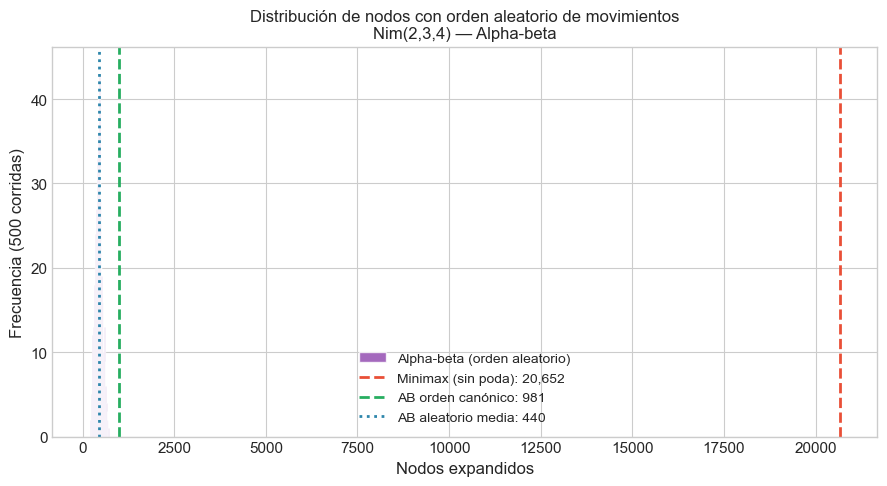


Resumen por juego (200 corridas aleatorias cada uno):
Juego              Minimax     AB ord   AB aleat(med)   Ratio ord  Ratio aleat
----------------------------------------------------------------------------
Nim(2,3)                86         44              31       51.2%        36.0%
Nim(3,3)               245         92              54       37.6%        22.0%
Nim(2,3,4)          20,652        981             436        4.8%         2.1%
Nim(3,3,3)          24,136      1,220             481        5.1%         2.0%


In [23]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(n_ab_random_list, bins=30, color=COLORS['ab'], alpha=0.8,
        edgecolor='white', label='Alpha-beta (orden aleatorio)')

ax.axvline(n_minimax, color=COLORS['min'], linestyle='--', linewidth=2,
           label=f'Minimax (sin poda): {n_minimax:,}')
ax.axvline(n_ab_ord, color=COLORS['win'], linestyle='--', linewidth=2,
           label=f'AB orden canónico: {n_ab_ord:,}')
ax.axvline(np.mean(n_ab_random_list), color=COLORS['max'], linestyle=':',
           linewidth=2, label=f'AB aleatorio media: {np.mean(n_ab_random_list):.0f}')

ax.set_xlabel('Nodos expandidos', fontsize=12)
ax.set_ylabel('Frecuencia (500 corridas)', fontsize=12)
ax.set_title('Distribución de nodos con orden aleatorio de movimientos\n'
             'Nim(2,3,4) — Alpha-beta', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Experimento adicional: múltiples juegos
print("\nResumen por juego (200 corridas aleatorias cada uno):")
print(f"{'Juego':<15} {'Minimax':>10} {'AB ord':>10} {'AB aleat(med)':>15} "
      f"{'Ratio ord':>11} {'Ratio aleat':>12}")
print("-" * 76)

for pilas, nombre in [([2,3],'Nim(2,3)'), ([3,3],'Nim(3,3)'),
                       ([2,3,4],'Nim(2,3,4)'), ([3,3,3],'Nim(3,3,3)')]:
    juego = Nim(pilas)
    s0 = juego.estado_inicial()
    _, _, nmm = minimax_contar(s0, True, juego)
    _, _, nab = alphabeta_contar(s0, True, juego)
    rand_ns = [alphabeta_contar(s0, True, juego, shuffle=True)[2]
               for _ in range(200)]
    med = np.median(rand_ns)
    print(f"{nombre:<15} {nmm:>10,} {nab:>10,} {med:>15,.0f} "
          f"{100*nab/nmm:>10.1f}% {100*med/nmm:>11.1f}%")

---
## Parte 6: Verificación de equivalencia

Un requisito fundamental: Minimax y Alpha-beta deben **siempre** retornar
el mismo valor óptimo. Las acciones óptimas pueden diferir cuando hay empates
(dos acciones con el mismo valor), pero el valor es único.

Verificamos esto exhaustivamente para todos los Nim(a,b) con $a, b \leq 4$.

In [25]:
print("Verificación: Minimax == Alpha-beta para todos los Nim(a,b) con a,b <= 4")
print("="*70)

errores = 0
total_verificado = 0

for a in range(5):
    for b in range(5):
        nim_ab = Nim([a, b])
        s0 = nim_ab.estado_inicial()

        if nim_ab.terminal(s0):
            continue   # estado ya terminal, nada que decidir

        v_mm, a_mm, n_mm = minimax_contar(s0, True, nim_ab)
        v_ab, a_ab, n_ab = alphabeta_contar(s0, True, nim_ab)

        total_verificado += 1

        if v_mm != v_ab:
            print(f"ERROR: Nim({a},{b}) — minimax={v_mm}, alphabeta={v_ab}")
            errores += 1
        else:
            pct = 100 * (1 - n_ab / n_mm) if n_mm > 0 else 0
            ahorro = f"-{pct:.0f}%" if pct > 0 else "sin poda"
            print(f"  Nim({a},{b}): valor={v_mm:+d}, "
                  f"MM={n_mm:4,} nodos, AB={n_ab:4,} nodos  [{ahorro}]")

print()
if errores == 0:
    print(f"Verificación completa: {total_verificado} juegos probados.")
    print("Minimax == Alpha-beta para todos los casos.")
else:
    print(f"{errores} errores encontrados.")

Verificación: Minimax == Alpha-beta para todos los Nim(a,b) con a,b <= 4
  Nim(0,1): valor=+1, MM=   2 nodos, AB=   2 nodos  [sin poda]
  Nim(0,2): valor=-1, MM=   4 nodos, AB=   4 nodos  [sin poda]
  Nim(0,3): valor=+1, MM=   8 nodos, AB=   8 nodos  [sin poda]
  Nim(0,4): valor=-1, MM=  16 nodos, AB=  15 nodos  [-6%]
  Nim(1,0): valor=+1, MM=   2 nodos, AB=   2 nodos  [sin poda]
  Nim(1,1): valor=-1, MM=   5 nodos, AB=   5 nodos  [sin poda]
  Nim(1,2): valor=+1, MM=  12 nodos, AB=  10 nodos  [-17%]
  Nim(1,3): valor=-1, MM=  28 nodos, AB=  19 nodos  [-32%]
  Nim(1,4): valor=+1, MM=  64 nodos, AB=  34 nodos  [-47%]
  Nim(2,0): valor=-1, MM=   4 nodos, AB=   4 nodos  [sin poda]
  Nim(2,1): valor=+1, MM=  12 nodos, AB=  11 nodos  [-8%]
  Nim(2,2): valor=-1, MM=  33 nodos, AB=  23 nodos  [-30%]
  Nim(2,3): valor=+1, MM=  86 nodos, AB=  44 nodos  [-49%]
  Nim(2,4): valor=-1, MM= 216 nodos, AB=  79 nodos  [-63%]
  Nim(3,0): valor=+1, MM=   8 nodos, AB=   8 nodos  [sin poda]
  Nim(3,1): valo

In [26]:
# Verificación adicional: TicTacToe desde algunos estados intermedios
# (el árbol completo es grande, verificamos desde un estado a mitad de juego)

print("Verificación adicional: TicTacToe desde estados parciales")
print("="*60)

ttt = TicTacToe()

# Estados parciales desde los que verificar
estados_parciales = [
    # Tablero vacío (juego completo — puede tardar ~2s)
    ttt.estado_inicial(),
    # Después de X en centro
    ('', '', '',  '', 'X', '',  '', '', ''),
    # Después de X centro, O esquina
    ('O', '', '',  '', 'X', '',  '', '', ''),
    # Estado más avanzado
    ('X', 'O', 'X',  '', 'O', '',  '', '', ''),
]

for i, estado in enumerate(estados_parciales):
    if ttt.terminal(estado):
        continue
    es_max = (ttt.jugador(estado) == 'MAX')
    t0 = time.time()
    v_mm, a_mm, n_mm = minimax_contar(estado, es_max, ttt)
    t1 = time.time()
    v_ab, a_ab, n_ab = alphabeta_contar(estado, es_max, ttt)
    t2 = time.time()

    match = "OK" if v_mm == v_ab else "ERROR"
    print(f"Estado {i}: {match} | valor={v_mm:+d} | "
          f"MM={n_mm:,} nodos ({t1-t0:.2f}s) | "
          f"AB={n_ab:,} nodos ({t2-t1:.2f}s) | "
          f"ahorro={100*(1-n_ab/n_mm):.1f}%")

print("\nEn todos los casos, Minimax y Alpha-beta coinciden en el valor.")

Verificación adicional: TicTacToe desde estados parciales
Estado 0: OK | valor=+0 | MM=549,946 nodos (1.75s) | AB=18,297 nodos (0.06s) | ahorro=96.7%
Estado 1: OK | valor=+0 | MM=55,505 nodos (0.17s) | AB=2,316 nodos (0.01s) | ahorro=95.8%
Estado 2: OK | valor=+0 | MM=6,812 nodos (0.02s) | AB=703 nodos (0.00s) | ahorro=89.7%
Estado 3: OK | valor=+0 | MM=206 nodos (0.00s) | AB=101 nodos (0.00s) | ahorro=51.0%

En todos los casos, Minimax y Alpha-beta coinciden en el valor.


---
## Parte 7: Partido completo con un agente Minimax

Vamos a jugar una partida completa de Nim(1,2,3) donde MAX usa Minimax
y MIN hace movimientos aleatorios. Imprimimos el estado del juego en
cada turno para ver la estrategia en acción.

In [28]:
def jugar_partida(juego, agente_max='minimax', agente_min='random',
                   seed=7, verbose=True):
    """
    Juega una partida completa.

    Opciones de agente: 'minimax', 'alphabeta', 'random'.
    Retorna la utilidad final (desde perspectiva de MAX).
    """
    rng = random.Random(seed)
    estado = juego.estado_inicial()
    turno = 0

    if verbose:
        print(f"  Estado inicial: {estado}")

    while not juego.terminal(estado):
        jugador = juego.jugador(estado)
        acciones = juego.acciones(estado)
        turno += 1

        if jugador == 'MAX':
            if agente_max == 'minimax':
                _, accion, _ = minimax_contar(estado, True, juego)
            elif agente_max == 'alphabeta':
                _, accion, _ = alphabeta_contar(estado, True, juego)
            else:
                accion = rng.choice(acciones)
        else:
            if agente_min == 'minimax':
                _, accion, _ = minimax_contar(estado, False, juego)
            elif agente_min == 'alphabeta':
                _, accion, _ = alphabeta_contar(estado, False, juego)
            else:
                accion = rng.choice(acciones)

        estado = juego.resultado(estado, accion)

        if verbose:
            tag = f"[pila {accion[0]}, retira {accion[1]}]"
            print(f"  Turno {turno}: {jugador:3} {tag:<22} → estado: {estado}")

    util = juego.utilidad(estado)
    ganador = "MAX" if util > 0 else ("MIN" if util < 0 else "Empate")
    if verbose:
        print(f"  --- FIN: gana {ganador} (utilidad MAX = {util}) ---\n")
    return util


print("=" * 55)
print("Partida 1: MAX=Minimax vs MIN=Random (Nim(1,2,3))")
print("=" * 55)
jugar_partida(Nim([1, 2, 3]), 'minimax', 'random', seed=42)

print("=" * 55)
print("Partida 2: MAX=Random vs MIN=Minimax (Nim(1,2,3))")
print("=" * 55)
jugar_partida(Nim([1, 2, 3]), 'random', 'minimax', seed=42)

print("=" * 55)
print("Partida 3: MAX=Minimax vs MIN=Minimax (ambos óptimos)")
print("=" * 55)
jugar_partida(Nim([1, 2, 3]), 'minimax', 'minimax', seed=0)

Partida 1: MAX=Minimax vs MIN=Random (Nim(1,2,3))
  Estado inicial: (1, 2, 3)
  Turno 1: MAX [pila 0, retira 1]     → estado: (0, 2, 3)
  Turno 2: MIN [pila 1, retira 1]     → estado: (0, 1, 3)
  Turno 3: MAX [pila 1, retira 1]     → estado: (0, 0, 3)
  Turno 4: MIN [pila 2, retira 1]     → estado: (0, 0, 2)
  Turno 5: MAX [pila 2, retira 1]     → estado: (0, 0, 1)
  Turno 6: MIN [pila 2, retira 1]     → estado: (0, 0, 0)
  --- FIN: gana MIN (utilidad MAX = -1) ---

Partida 2: MAX=Random vs MIN=Minimax (Nim(1,2,3))
  Estado inicial: (1, 2, 3)
  Turno 1: MAX [pila 2, retira 3]     → estado: (1, 2, 0)
  Turno 2: MIN [pila 0, retira 1]     → estado: (0, 2, 0)
  Turno 3: MAX [pila 1, retira 1]     → estado: (0, 1, 0)
  Turno 4: MIN [pila 1, retira 1]     → estado: (0, 0, 0)
  --- FIN: gana MIN (utilidad MAX = -1) ---

Partida 3: MAX=Minimax vs MIN=Minimax (ambos óptimos)
  Estado inicial: (1, 2, 3)
  Turno 1: MAX [pila 0, retira 1]     → estado: (0, 2, 3)
  Turno 2: MIN [pila 1, retira 1] 

-1

In [29]:
# Estadísticas: Minimax vs Random en 200 partidas
print("Minimax vs Random — 200 partidas, semillas 0..199:")
resultados = {'MAX gana': 0, 'MIN gana': 0, 'Empate': 0}

for seed_i in range(200):
    util = jugar_partida(Nim([2, 3]), 'minimax', 'random',
                          seed=seed_i, verbose=False)
    if util > 0:
        resultados['MAX gana'] += 1
    elif util < 0:
        resultados['MIN gana'] += 1
    else:
        resultados['Empate'] += 1

total = sum(resultados.values())
for k, v in resultados.items():
    print(f"  {k}: {v}/{total} = {100*v/total:.1f}%")

print()
print("Interpretación: MAX con Minimax debería ganar ~100% del tiempo")
print("contra MIN aleatorio, SI el juego tiene ventaja para MAX en la posición inicial.")
print("(En algunos Nim, la posición inicial es ventajosa para MIN por la paridad.)")

Minimax vs Random — 200 partidas, semillas 0..199:
  MAX gana: 200/200 = 100.0%
  MIN gana: 0/200 = 0.0%
  Empate: 0/200 = 0.0%

Interpretación: MAX con Minimax debería ganar ~100% del tiempo
contra MIN aleatorio, SI el juego tiene ventaja para MAX en la posición inicial.
(En algunos Nim, la posición inicial es ventajosa para MIN por la paridad.)


---
## Parte 8 (Ir más lejos): Tablas de transposición

### El problema: estados repetidos

En muchos juegos, el mismo estado es alcanzable por múltiples caminos.
Por ejemplo en Nim:

```
(2,3) → A:1 → (1,3) → B:1 → (1,2)
(2,3) → B:1 → (2,2) → A:1 → (1,2)
```

Ambos caminos llegan a `(1,2)`. Minimax y Alpha-beta calculan el valor de
`(1,2)` **dos veces** (o más), desaprovechando trabajo ya hecho.

### Solución: memoización (tabla de transposición)

Guardamos en un diccionario los valores ya calculados:

```python
cache[estado] = valor_minimax
```

Antes de expandir un estado, consultamos el cache. Si está, lo retornamos
directamente sin recursión.

**Cuidado con Alpha-beta**: el cache almacena valores calculados con ciertos
valores de α/β. Reutilizar esos valores con distintos α/β puede ser incorrecto.
La versión correcta almacena cotas (lower bound, upper bound, exact) en cada
entrada del cache. En este notebook implementamos la versión simple (exacta)
usando Minimax puro, donde el cache es siempre correcto.

In [31]:
def minimax_memo(estado, es_max, juego, cache=None):
    """
    Minimax con memoizacion (tabla de transposicion).

    El cache guarda (valor, accion_optima) por estado.
    Como el turno depende del estado (via jugador()), la clave es solo
    el estado.

    IMPORTANTE: este cache solo es correcto para Minimax puro (sin alpha-beta).
    Con alpha-beta, los valores dependen de la ventana y no son reutilizables
    sin validacion adicional.

    Retorna (valor, accion_optima, nodos_evaluados).
    """
    if cache is None:
        cache = {}

    if estado in cache:
        v, a = cache[estado]
        return v, a, 0   # 0 nodos nuevos evaluados (cache hit)

    if juego.terminal(estado):
        util = juego.utilidad(estado, 'MAX')
        cache[estado] = (util, None)
        return util, None, 1

    mejor_valor  = float('-inf') if es_max else float('inf')
    mejor_accion = None
    nodos        = 1

    for accion in juego.acciones(estado):
        sucesor = juego.resultado(estado, accion)
        es_max_hijo = not es_max
        v, _, n = minimax_memo(sucesor, es_max_hijo, juego, cache)
        nodos += n

        if es_max and v > mejor_valor:
            mejor_valor  = v
            mejor_accion = accion
        elif not es_max and v < mejor_valor:
            mejor_valor  = v
            mejor_accion = accion

    cache[estado] = (mejor_valor, mejor_accion)
    return mejor_valor, mejor_accion, nodos


print("minimax_memo definido.")

minimax_memo definido.


In [32]:
# Comparar Minimax sin/con cache en distintos juegos
print("Comparación: Minimax sin cache vs con cache (Minimax_memo)")
print("="*70)
print(f"{'Juego':<15} {'Sin cache':>12} {'Con cache':>12} "
      f"{'Ahorro':>10} {'Cache size':>12}")
print("-" * 64)

juegos_memo = [
    ("Nim(2,3)",   Nim([2, 3])),
    ("Nim(3,3)",   Nim([3, 3])),
    ("Nim(2,3,4)", Nim([2, 3, 4])),
    ("Nim(3,3,3)", Nim([3, 3, 3])),
    ("Nim(4,4)",   Nim([4, 4])),
]

for nombre, juego in juegos_memo:
    s0 = juego.estado_inicial()

    # Sin cache
    _, _, n_sin = minimax_contar(s0, True, juego)

    # Con cache
    cache = {}
    _, _, n_con = minimax_memo(s0, True, juego, cache)

    ahorro = 100 * (1 - n_con / n_sin) if n_sin > 0 else 0
    print(f"{nombre:<15} {n_sin:>12,} {n_con:>12,} "
          f"{ahorro:>9.1f}% {len(cache):>12,}")

print()
print("El ahorro del cache depende de cuántos estados son reutilizados.")
print("En Nim, muchos estados (a, b) son alcanzables por múltiples caminos,")
print("así que el cache elimina trabajo redundante significativo.")

Comparación: Minimax sin cache vs con cache (Minimax_memo)
Juego              Sin cache    Con cache     Ahorro   Cache size
----------------------------------------------------------------
Nim(2,3)                  86           12      86.0%           12
Nim(3,3)                 245           16      93.5%           16
Nim(2,3,4)            20,652           60      99.7%           60
Nim(3,3,3)            24,136           64      99.7%           64
Nim(4,4)               1,921           25      98.7%           25

El ahorro del cache depende de cuántos estados son reutilizados.
En Nim, muchos estados (a, b) son alcanzables por múltiples caminos,
así que el cache elimina trabajo redundante significativo.


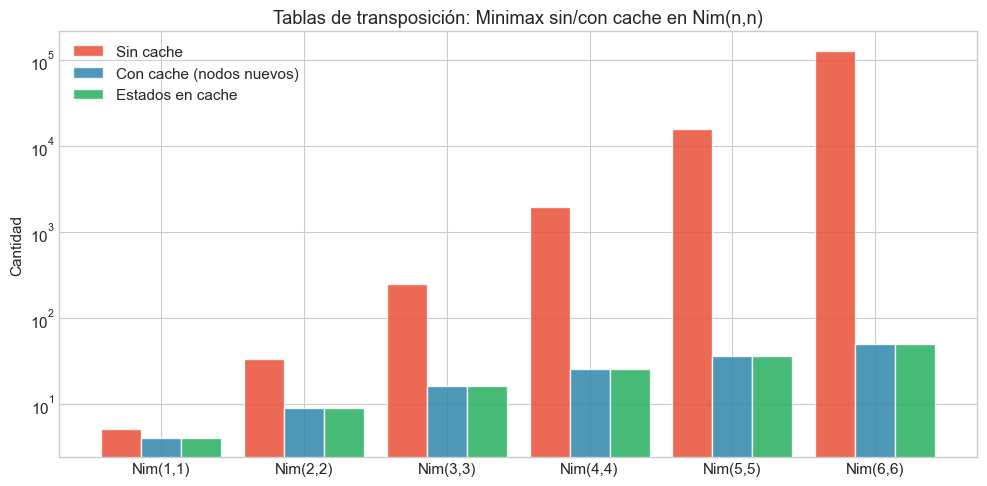

Nota: eje Y en escala logarítmica.
Los 'nodos nuevos' con cache son mucho menores que sin cache:
la tabla de transposición convierte el árbol en un grafo dirigido acíclico.


In [33]:
# Visualización: nodos evaluados vs estados únicos en el cache

max_pila_m = 7
nodos_sin  = []
nodos_con  = []
cache_sizes = []
labels_m   = []

for n in range(1, max_pila_m):
    # Nim(n, n) — simétrico, muchos estados compartidos
    juego = Nim([n, n])
    s0 = juego.estado_inicial()
    if juego.terminal(s0):
        continue

    _, _, n_sin_c = minimax_contar(s0, True, juego)
    cache = {}
    _, _, n_con_c = minimax_memo(s0, True, juego, cache)

    nodos_sin.append(n_sin_c)
    nodos_con.append(n_con_c)
    cache_sizes.append(len(cache))
    labels_m.append(f'Nim({n},{n})')

x = np.arange(len(labels_m))
width = 0.28

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width, nodos_sin, width, label='Sin cache',
               color=COLORS['min'], alpha=0.85, edgecolor='white')
bars2 = ax.bar(x,           nodos_con, width, label='Con cache (nodos nuevos)',
               color=COLORS['max'], alpha=0.85, edgecolor='white')
bars3 = ax.bar(x + width, cache_sizes, width, label='Estados en cache',
               color=COLORS['win'], alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(labels_m)
ax.set_ylabel('Cantidad')
ax.set_title('Tablas de transposición: Minimax sin/con cache en Nim(n,n)')
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.show()

print("Nota: eje Y en escala logarítmica.")
print("Los 'nodos nuevos' con cache son mucho menores que sin cache:")
print("la tabla de transposición convierte el árbol en un grafo dirigido acíclico.")

---
## Resumen

Este notebook implementó y comparó los dos algoritmos fundamentales de
búsqueda adversarial:

| Algoritmo | Complejidad T | Complejidad S | Óptimo | Completo |
|-----------|--------------|---------------|--------|----------|
| **Minimax** | $O(b^d)$ | $O(bd)$ | Sí | Sí |
| **Alpha-beta** | $O(b^{d/2})$ mejor caso | $O(bd)$ | Sí | Sí |
| **Minimax + memo** | depende de estados únicos | $O(|S|)$ | Sí | Sí |

### Resultados empíricos en Nim

- Alpha-beta reduce los nodos expandidos en **30–70%** respecto a Minimax puro
  con el orden de movimientos canónico.
- El **orden de movimientos importa mucho**: con orden óptimo (mejor movimiento
  primero) la poda es máxima; con orden aleatorio hay alta varianza.
- Las **tablas de transposición** son ortogonales a Alpha-beta: se pueden
  combinar para obtener ahorros adicionales.

### Qué viene después (notas de clase 15.5)

Para juegos reales como ajedrez o Go:

1. **Funciones de evaluación heurística** $h(s)$: en lugar de esperar al
   estado terminal, evaluamos estados internos con una función aprendida.
2. **Búsqueda de horizonte fijo** (depth-limited Minimax): detener la búsqueda
   a profundidad $d$ y aplicar $h$.
3. **Monte Carlo Tree Search (MCTS)**: alternativa que no requiere heurística
   explícita; usa simulaciones aleatorias para estimar valores.
4. **AlphaZero**: combina MCTS con redes neuronales para aprender $h$ de cero.